In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("taxis")

df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:

df.shape

(6433, 14)

In [3]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [4]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [5]:
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])



In [6]:
df["pickup_borough"] = df["pickup_borough"].fillna(df["pickup_borough"].mode()[0])
df["dropoff_borough"] = df["dropoff_borough"].fillna(df["dropoff_borough"].mode()[0])

In [7]:
df["pickup_zone"]=df["pickup_zone"].fillna(df["pickup_zone"].mode()[0])
df["dropoff_zone"]=df["dropoff_zone"].fillna(df["dropoff_zone"].mode()[0])

In [8]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


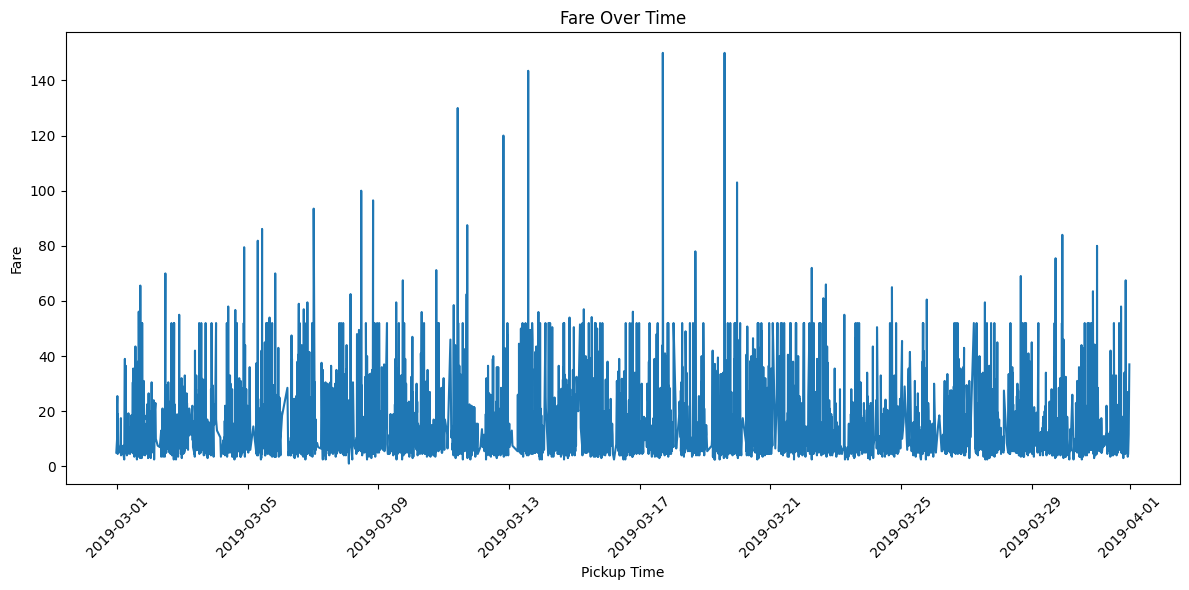

In [9]:

df["pickup"] = pd.to_datetime(df["pickup"])

df = df.sort_values("pickup")

plt.figure(figsize=(12, 6))

plt.plot(df["pickup"], df["fare"])

plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

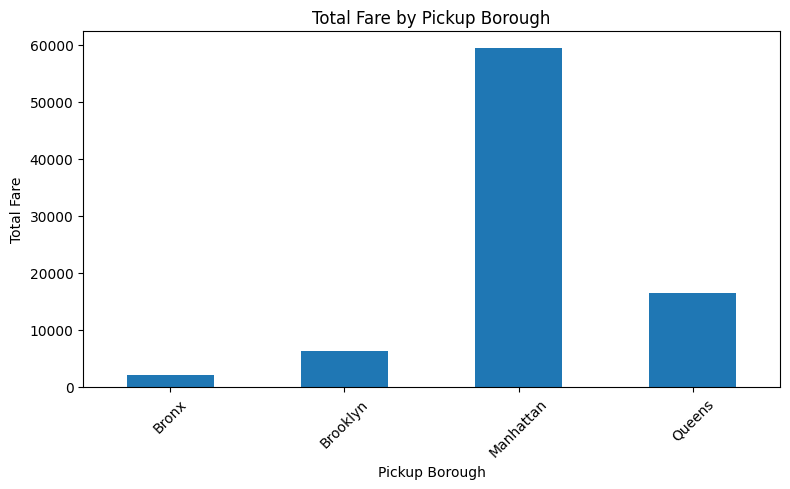

In [10]:

borough_fare = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(8, 5))

borough_fare.plot(kind="bar")

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

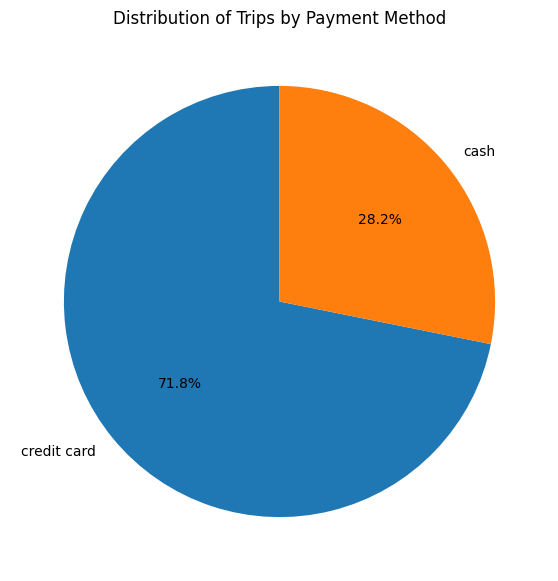

In [11]:
payment_counts = df['payment'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Trips by Payment Method')
plt.show()

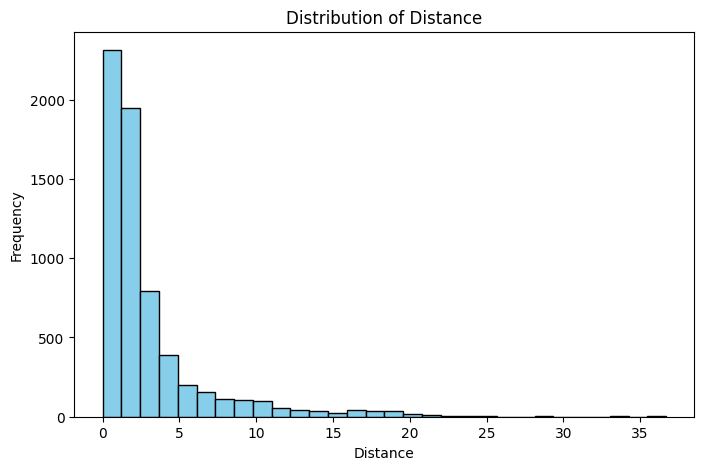

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['distance'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

<Figure size 800x500 with 0 Axes>

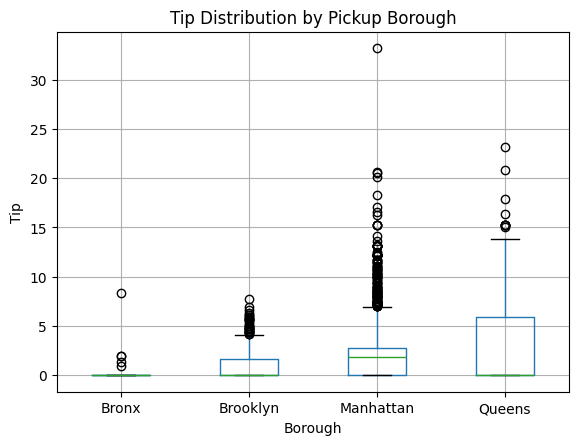

In [13]:
plt.figure(figsize=(8,5))
df.boxplot(column='tip', by='pickup_borough')
plt.title('Tip Distribution by Pickup Borough')
plt.suptitle('')
plt.xlabel('Borough')
plt.ylabel('Tip')
plt.show()

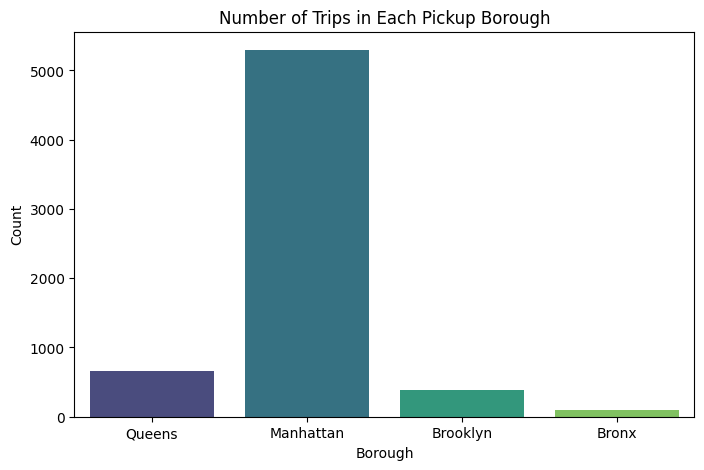

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='pickup_borough', data=df, hue='pickup_borough', palette='viridis', legend=False)
plt.title('Number of Trips in Each Pickup Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.show()

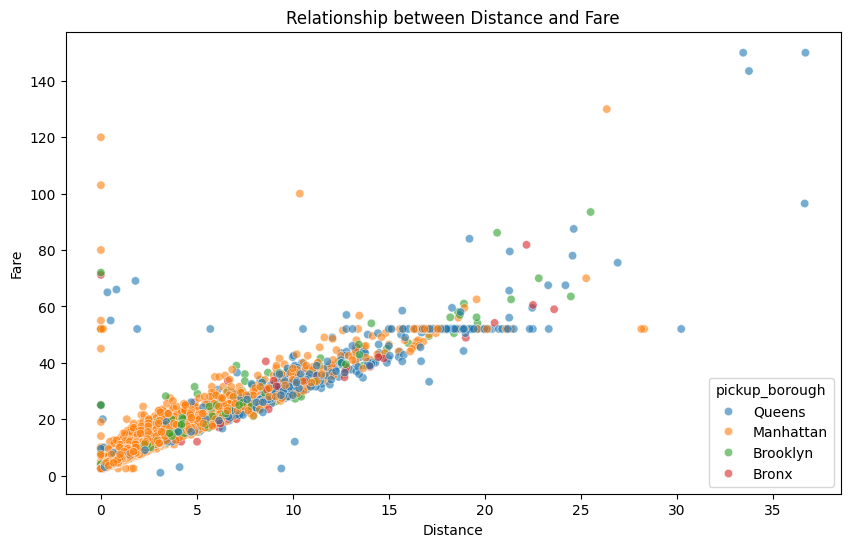

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df, alpha=0.6)
plt.title('Relationship between Distance and Fare')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.show()

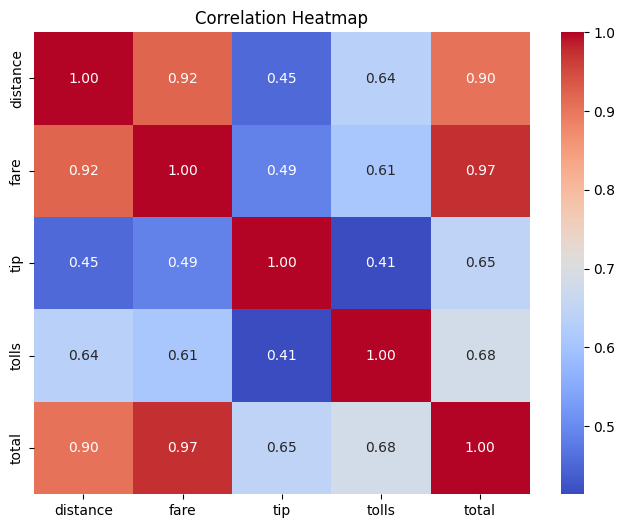

In [16]:

numeric_df = df[['distance', 'fare', 'tip', 'tolls', 'total']]

plt.figure(figsize=(8,6))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

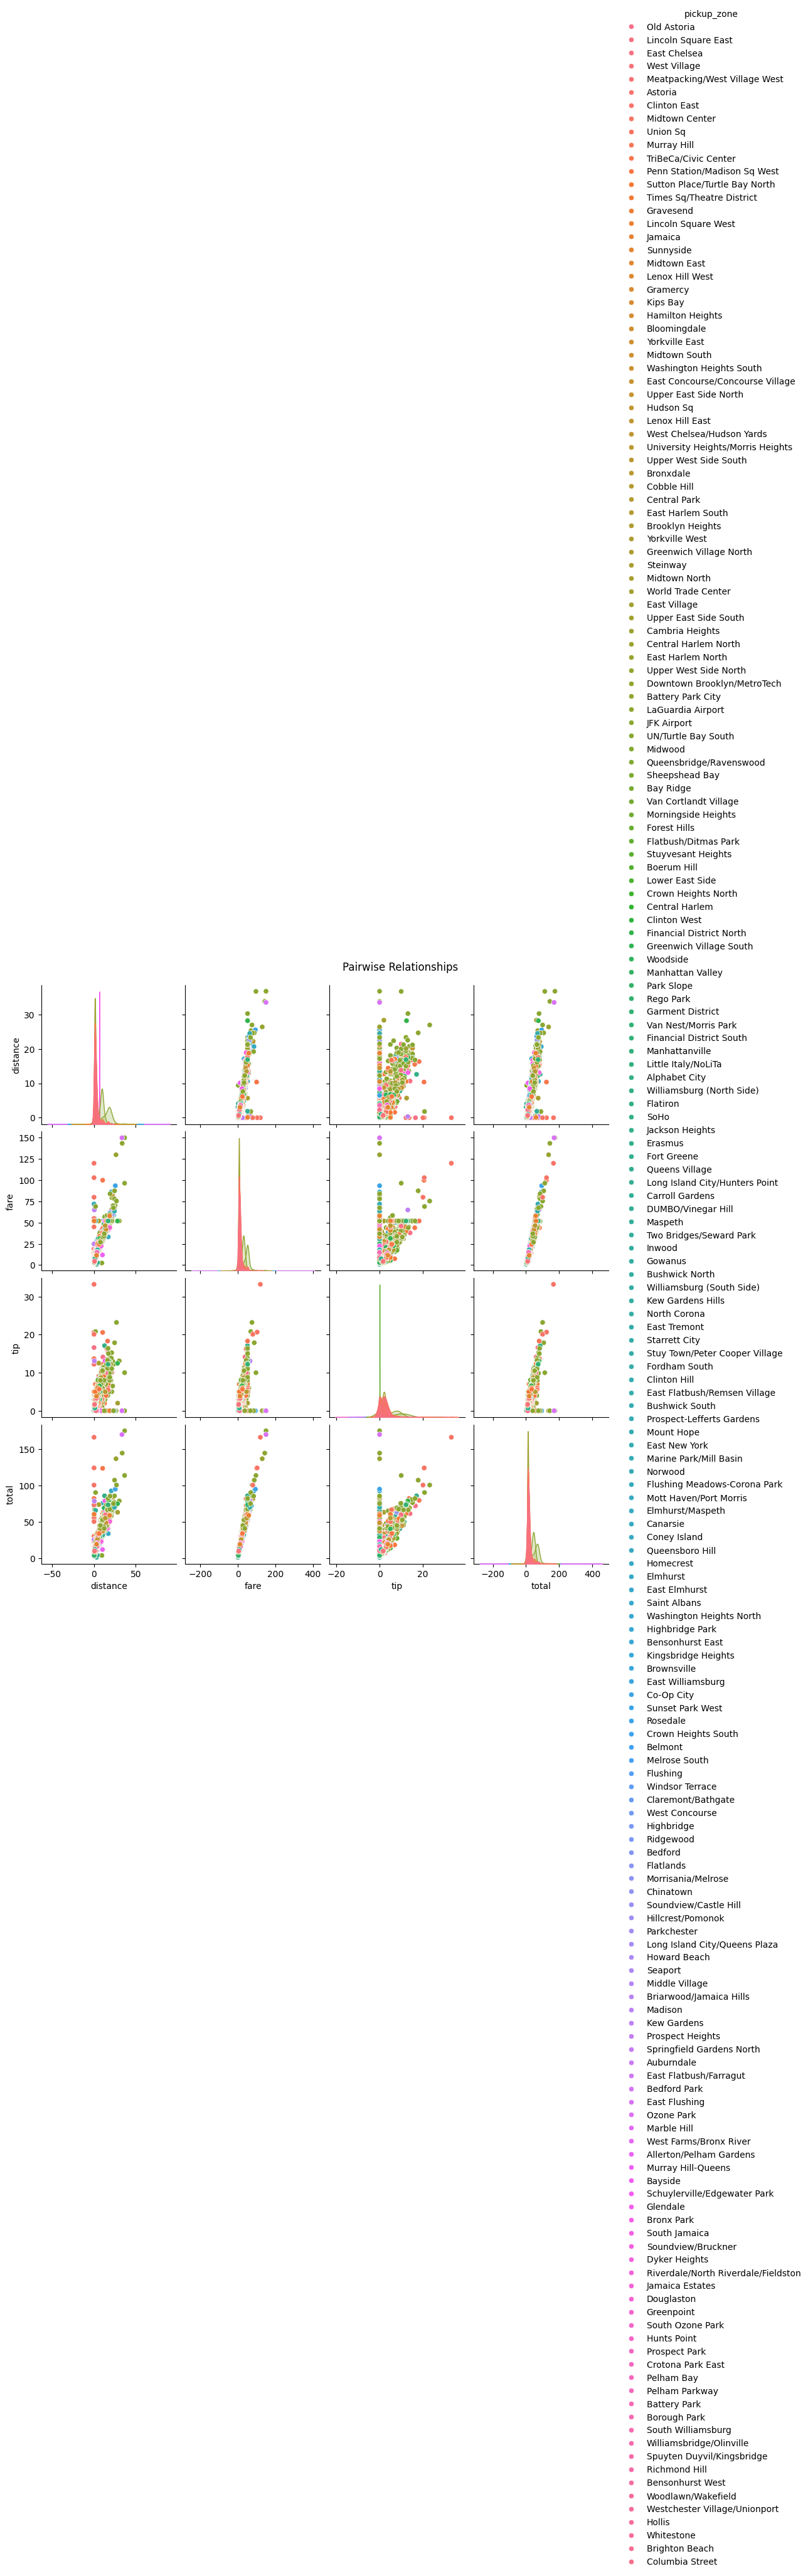

In [17]:

sns.pairplot(df[['distance', 'fare', 'tip', 'total', 'pickup_zone']], hue='pickup_zone', diag_kind='kde')
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

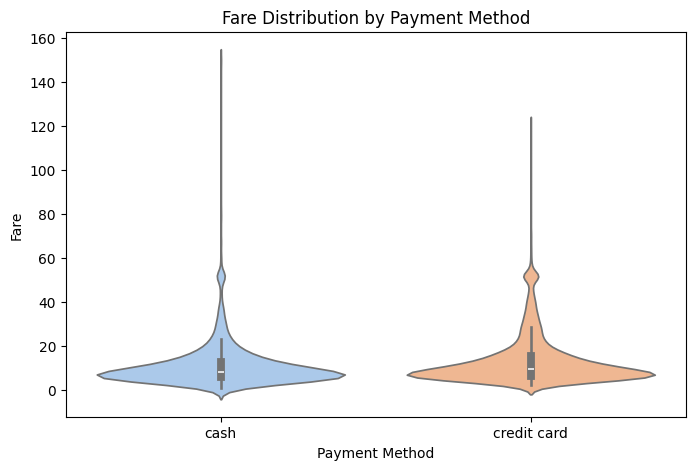

In [22]:
plt.figure(figsize=(8,5))
sns.violinplot(x='payment', y='fare', data=df, hue='payment', palette='pastel', legend=False)
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.show()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6433 entries, 6203 to 591
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6433 non-null   object        
 10  pickup_zone      6433 non-null   object        
 11  dropoff_zone     6433 non-null   object        
 12  pickup_borough   6433 non-null   object        
 13  dropoff_borough  6433 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1),